# 📉 Customer Churn Prediction in the Telecom Sector

**Author:** ***Misgina Gebregergs***  
**Project Type:** **End-to-End Machine Learning Classification**  
**Primary Model:** ***XGBoost***  
**Techniques:** Feature Engineering, Stratified Cross-Validation, Hyperparameter Tuning, Imbalanced Classification, Probability Calibration, Threshold Optimization, SHAP Explainability

---

## 📌 1. Business Problem

Customer churn is a major challenge in the telecommunications industry. Identifying customers who are likely to leave allows companies to take preventive actions such as targeted retention campaigns, personalized offers, and improved customer support.

The objective of this project is to develop a reliable machine learning system that identifies customers who are at higher risk of churning based on their demographic, service, contract, account, and billing information.

---

## 🎯 2. Project Objective

The main objectives are to:

- Analyze customer characteristics associated with churn.
- Build a reliable binary classification system.
- Compare multiple machine learning models.
- Apply leakage-safe feature engineering and preprocessing.
- Use stratified cross-validation for reliable model evaluation.
- Optimize model hyperparameters.
- Handle class imbalance appropriately.
- Optimize the probability threshold based on validation performance.
- Calibrate predicted probabilities.
- Explain model predictions using SHAP.
- Evaluate the final selected model on an untouched test set.

---

## 📊 3. Dataset

The dataset contains customer-level information from a telecommunications service provider.

**Target Variable:** `Churn`

The data includes information related to:

- Customer demographics
- Account information
- Contract type
- Internet and telephone services
- Payment methods
- Monthly and total charges
- Customer tenure
- Additional subscribed services

The dataset is cleaned, validated, transformed, and prepared through a reproducible machine learning pipeline.

---

## 🧠 4. Machine Learning Approach

The project follows an end-to-end machine learning workflow:

**Data Understanding → Data Cleaning → Feature Engineering → Preprocessing → Model Benchmarking → Stratified Cross-Validation → Hyperparameter Tuning → Class-Imbalance Handling → Model Selection → Probability Calibration → Threshold Optimization → Explainability → Final Test Evaluation**

The main models include:

1. **Logistic Regression** — baseline linear classifier.
2. **Random Forest** — nonlinear ensemble model.
3. **HistGradientBoosting** — gradient boosting model.
4. **XGBoost** — advanced gradient boosting model and primary candidate.

Model selection is based on validation performance, with particular attention to **PR-AUC** because churn prediction may involve class imbalance.

---

## 📈 5. Model Evaluation

Models are evaluated using multiple classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix

The validation set is used for model selection and threshold optimization, while the final test set remains untouched until the final evaluation.

---

## 💼 6. Business Objective

The ultimate goal is to answer a practical business question:

> **Which customers are most likely to churn, and how can these predictions support effective customer-retention decisions?**

The model can help prioritize high-risk customers for targeted retention strategies while allowing the business to balance the cost of false positives against the cost of missing potential churners.

---

## 🛠️ Technologies

**Python • Pandas • NumPy • Matplotlib • Seaborn • Scikit-learn • XGBoost • SHAP • Joblib • Jupyter Notebook • Google Colab**

In [3]:
# 1. Imports and configuration
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, brier_score_loss, roc_curve,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

RANDOM_STATE = 42
DATA_PATH = Path("/content/Telco-Customer-Churn.csv")
ARTIFACT_DIR = Path("artifacts")
FIGURE_DIR = Path("figures")
ARTIFACT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_STATE)
print("Ready:", DATA_PATH)


Ready: /content/Telco-Customer-Churn.csv


## 2. Stage 1 — Inspect the actual dataset

We inspect shape, types, missing values, duplicates, identifiers, distributions and suspicious values before modeling.


In [4]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())
display(df.nunique().sort_values().to_frame("unique_values"))


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Duplicate rows: 0
Duplicate customer IDs: 0


,unique_values
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
MultipleLines,3
TechSupport,3
StreamingTV,3


In [5]:
# Recognize whitespace-only strings as missing for inspection
inspection = df.copy()
for col in inspection.select_dtypes(include="object").columns:
    inspection[col] = inspection[col].replace(r"^\s*$", np.nan, regex=True)

display(inspection.isna().sum().sort_values(ascending=False).to_frame("missing_after_whitespace_check"))

print("Target distribution:")
target_summary = df["Churn"].value_counts().to_frame("count")
target_summary["percentage"] = df["Churn"].value_counts(normalize=True).mul(100)
display(target_summary)

print("Numerical summary:")
display(
    inspection[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]]
    .assign(TotalCharges=pd.to_numeric(inspection["TotalCharges"], errors="coerce"))
    .describe().T
)


,missing_after_whitespace_check
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


Target distribution:


,count,percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


Numerical summary:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


### Stage 1 findings

The uploaded dataset contains **7,043 rows and 21 columns**. `customerID` is unique and is treated as an identifier rather than a predictive feature. `TotalCharges` contains whitespace values that must be treated as missing before numeric conversion. The target is moderately imbalanced, so accuracy alone will not be sufficient.

The exact values used in the project are calculated from the dataset by the cells above; no model result is hard-coded.


## 3. Stage 2 — Problem formulation

**Business problem:** identify customers at elevated risk of churn so retention resources can be prioritized.

**ML problem:** binary classification.

- Positive class: `Churn = Yes`
- Negative class: `Churn = No`

We track accuracy, precision, recall, F1, ROC-AUC, PR-AUC and Brier score. PR-AUC is particularly useful because churn is the minority class.

False negatives can represent missed retention opportunities. False positives can waste retention resources. If reliable monetary costs become available, the threshold can be optimized against expected cost.


## 4. Stage 3 — Professional cleaning

Whitespace-only categorical values are converted to missing values. `TotalCharges` is converted to numeric. We retain the zero-tenure records rather than silently deleting them; the preprocessing pipeline handles their missing `TotalCharges` values.


In [6]:
data = df.copy()

for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].replace(r"^\s*$", np.nan, regex=True)

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

print("TotalCharges missing:", data["TotalCharges"].isna().sum())
print("Duplicate rows:", data.duplicated().sum())
print("Duplicate IDs:", data["customerID"].duplicated().sum())


TotalCharges missing: 11
Duplicate rows: 0
Duplicate IDs: 0


## 5. Stage 4 — Exploratory data analysis

The following plots focus on useful customer/churn relationships rather than creating charts for their own sake.


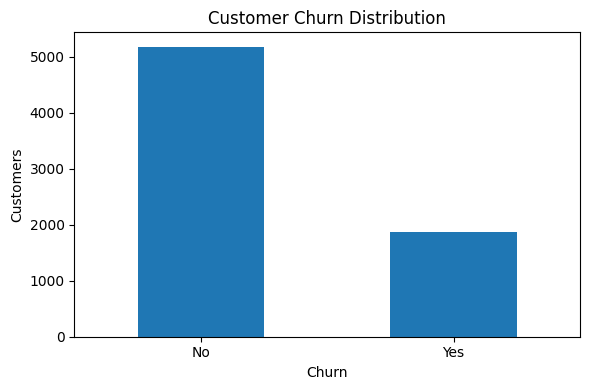

In [7]:
# Target distribution
counts = data["Churn"].value_counts()
plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", dpi=150)
plt.show()


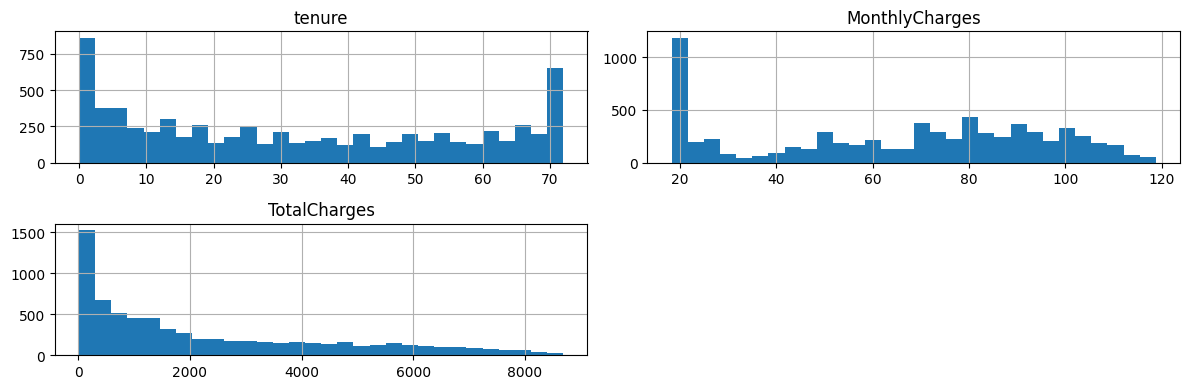

In [8]:
# Numerical distributions
eda_num = data[["tenure", "MonthlyCharges", "TotalCharges"]]
eda_num.hist(figsize=(12,4), bins=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "numeric_distributions.png", dpi=150)
plt.show()


In [9]:
# Churn rates for important categorical variables
eda_cols = [
    "Contract", "InternetService", "PaymentMethod",
    "OnlineSecurity", "TechSupport", "PaperlessBilling"
]

for col in eda_cols:
    rates = data.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)
    print("\n" + col)
    display((rates * 100).round(2).to_frame("churn_rate_%"))



Contract


,churn_rate_%
Contract,
Month-to-month,42.71
One year,11.27
Two year,2.83



InternetService


,churn_rate_%
InternetService,
Fiber optic,41.89
DSL,18.96
No,7.40



PaymentMethod


...

,churn_rate_%
OnlineSecurity,
No,41.77
Yes,14.61
No internet service,7.40



TechSupport


,churn_rate_%
TechSupport,
No,41.64
Yes,15.17
No internet service,7.40



PaperlessBilling


,churn_rate_%
PaperlessBilling,
Yes,33.57
No,16.33


,churn_rate_%
tenure_band,
0-6,52.94
7-12,35.89
13-24,28.71
25-48,20.39
49-72,9.51


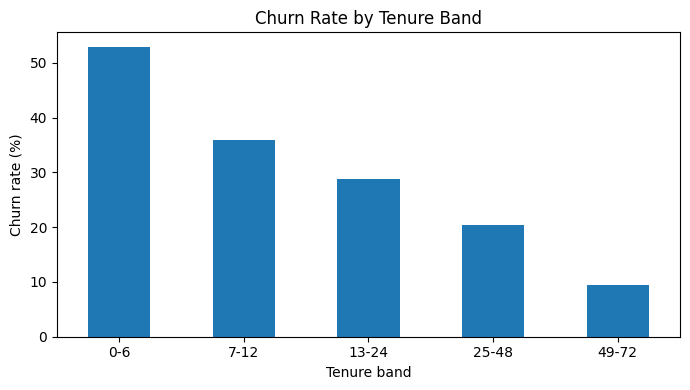

In [10]:
# Tenure bands
tenure_band = pd.cut(
    data["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)
rates = data.assign(tenure_band=tenure_band).groupby("tenure_band", observed=False)["Churn"].apply(
    lambda s: (s == "Yes").mean()
)
display((rates * 100).round(2).to_frame("churn_rate_%"))

plt.figure(figsize=(7,4))
(rates * 100).plot(kind="bar")
plt.title("Churn Rate by Tenure Band")
plt.xlabel("Tenure band")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "churn_by_tenure.png", dpi=150)
plt.show()


## 6. Stage 5 — Train / validation / test design

We use a stratified **70/15/15** split.

- Training: model fitting and cross-validation
- Validation: model comparison, calibration/threshold decisions
- Final test: one-time generalization estimate

The final test set is never used to tune hyperparameters, select features, select a threshold, or select an ensemble.


In [11]:
TARGET = "Churn"

X = data.drop(columns=[TARGET, "customerID"])
y = data[TARGET].map({"No": 0, "Yes": 1})

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Positive rates:", y_train.mean(), y_val.mean(), y_test.mean())


Train: (4930, 19)
Validation: (1056, 19)
Test: (1057, 19)
Positive rates: 0.2653144016227181 0.26515151515151514 0.26584673604541154


## 7. Stage 6–7 — Leakage-safe feature engineering

Feature engineering is implemented as a transformer so it runs identically during fitting and inference.

Engineered features are hypotheses and will be tested through an ablation experiment.


In [12]:
class ChurnFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        total = pd.to_numeric(X["TotalCharges"], errors="coerce")
        tenure = pd.to_numeric(X["tenure"], errors="coerce")
        monthly = pd.to_numeric(X["MonthlyCharges"], errors="coerce")

        X["avg_monthly_charge_from_total"] = np.where(
            tenure > 0, total / tenure, np.nan
        )
        X["total_to_monthly_ratio"] = np.where(
            monthly > 0, total / monthly, np.nan
        )
        X["tenure_months_squared"] = tenure ** 2
        X["is_new_customer"] = (tenure <= 1).astype(int)

        service_cols = [
            "PhoneService", "MultipleLines", "OnlineSecurity",
            "OnlineBackup", "DeviceProtection", "TechSupport",
            "StreamingTV", "StreamingMovies"
        ]
        X["service_count"] = sum(
            X[c].eq("Yes").astype(float) for c in service_cols if c in X.columns
        )
        X["has_security_support"] = (
            X["OnlineSecurity"].eq("Yes") | X["TechSupport"].eq("Yes")
        ).astype(int)

        return X


In [13]:
# Build preprocessing column lists from training data only.
fe_preview = ChurnFeatureEngineer().fit_transform(X_train)
numeric_features = fe_preview.select_dtypes(include=np.number).columns.tolist()
categorical_features = fe_preview.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

def make_pipeline(model):
    return Pipeline([
        ("features", ChurnFeatureEngineer()),
        ("preprocess", preprocessor),
        ("model", model)
    ])


## 8. Stage 8–9 — Baseline and advanced model benchmarking

We compare an interpretable Logistic Regression baseline with Random Forest, HistGradientBoosting, and XGBoost. No algorithm is assumed to be best in advance.


In [14]:
# Benchmark models on the same leakage-safe pipeline

# Compute the class imbalance ratio from training data only.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("XGBoost scale_pos_weight:", round(scale_pos_weight, 3))

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=250, learning_rate=0.05,
        max_leaf_nodes=31, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

def evaluate_predictions(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, prob),
        "PR_AUC": average_precision_score(y_true, prob),
        "Brier": brier_score_loss(y_true, prob)
    }

benchmark_rows = []
fitted_benchmarks = {}

for name, estimator in models.items():
    pipe = make_pipeline(estimator)
    pipe.fit(X_train, y_train)
    fitted_benchmarks[name] = pipe
    prob = pipe.predict_proba(X_val)[:, 1]
    row = evaluate_predictions(y_val, prob)
    row["Model"] = name
    benchmark_rows.append(row)

benchmark_df = pd.DataFrame(benchmark_rows).set_index("Model").sort_values("PR_AUC", ascending=False)
display(benchmark_df.round(4))


XGBoost scale_pos_weight: 2.769


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
Model,,,,,,,
Logistic Regression,0.7348,0.5000,0.8286,0.6237,0.8506,0.6582,0.1668
XGBoost,0.7585,0.5296,0.8000,0.6373,0.8410,0.6352,0.1610
HistGradientBoosting,0.7756,0.5939,0.4857,0.5344,0.8319,0.6202,0.1440
Random Forest,0.7756,0.5947,0.4821,0.5325,0.8186,0.5905,0.1490


## 9. Stage 10 — Cross-validation

Five-fold Stratified K-Fold CV measures both mean performance and stability for all four candidate models. PR-AUC is especially useful because churn is the minority class.


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, estimator in models.items():
    pipe = make_pipeline(estimator)
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={"roc_auc":"roc_auc", "pr_auc":"average_precision", "f1":"f1"},
        n_jobs=-1
    )
    cv_rows.append({
        "Model": name,
        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std(),
        "PR_AUC_mean": scores["test_pr_auc"].mean(),
        "PR_AUC_std": scores["test_pr_auc"].std(),
        "F1_mean": scores["test_f1"].mean(),
        "F1_std": scores["test_f1"].std()
    })

cv_df = pd.DataFrame(cv_rows).set_index("Model").sort_values("PR_AUC_mean", ascending=False)
display(cv_df.round(4))


,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std,F1_mean,F1_std
Model,,,,,,
Logistic Regression,0.8483,0.0098,0.6730,0.0244,0.6293,0.0192
XGBoost,0.8412,0.0124,0.6610,0.0223,0.6222,0.0201
Random Forest,0.8352,0.0091,0.6453,0.0185,0.5698,0.0177
HistGradientBoosting,0.8330,0.0110,0.6434,0.0220,0.5704,0.0169


## 10. Stage 11 — Hyperparameter optimization

RandomizedSearchCV is used with PR-AUC as the optimization objective. The search is confined to training data and cross-validation. Random Forest, HistGradientBoosting, and XGBoost are tuned independently.


In [18]:
rf_pipe = make_pipeline(RandomForestClassifier(
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
))

rf_params = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_params, n_iter=25, scoring="average_precision",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
rf_search.fit(X_train, y_train)

print("Best RF CV PR-AUC:", round(rf_search.best_score_, 4))
print(rf_search.best_params_)


Best RF CV PR-AUC: 0.6712
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 8, 'model__max_features': 'sqrt', 'model__max_depth': 10}


In [19]:
# HistGradientBoosting hyperparameter search
hgb_pipe = make_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE))

hgb_params = {
    "model__max_iter": [100, 200, 300, 500],
    "model__learning_rate": [0.02, 0.05, 0.08, 0.12],
    "model__max_leaf_nodes": [7, 15, 31, 63],
    "model__min_samples_leaf": [10, 20, 30, 50],
    "model__l2_regularization": [0, 0.1, 1, 5, 10]
}

hgb_search = RandomizedSearchCV(
    hgb_pipe, hgb_params, n_iter=25, scoring="average_precision",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
hgb_search.fit(X_train, y_train)

print("Best HGB CV PR-AUC:", round(hgb_search.best_score_, 4))
print(hgb_search.best_params_)


Best HGB CV PR-AUC: 0.6686
{'model__min_samples_leaf': 50, 'model__max_leaf_nodes': 7, 'model__max_iter': 100, 'model__learning_rate': 0.08, 'model__l2_regularization': 5}


### XGBoost hyperparameter optimization

XGBoost is tuned using the same leakage-safe preprocessing pipeline and five-fold cross-validation. The optimization metric is PR-AUC, matching the other tuned candidates.


In [20]:
# XGBoost hyperparameter optimization
xgb_pipe = make_pipeline(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

xgb_params = {
    "model__n_estimators": [200, 300, 500, 700, 1000],
    "model__max_depth": [2, 3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__gamma": [0, 0.1, 0.3, 0.5, 1],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 2, 5, 10]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_params,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost CV PR-AUC:", round(xgb_search.best_score_, 4))
print("Best XGBoost parameters:")
print(xgb_search.best_params_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGBoost CV PR-AUC: 0.6697
Best XGBoost parameters:
{'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 0.6}


## 11. Stage 12 — Imbalance handling

Logistic Regression and Random Forest use class weighting. XGBoost uses `scale_pos_weight`, calculated from the training data only. HistGradientBoosting remains unweighted. Threshold optimization later provides another way to control the precision/recall trade-off.


## 12. Stage 13 — Candidate selection and probability calibration

The tuned candidates are compared on validation data. The candidate with the strongest validation PR-AUC is selected for calibration. Calibration quality is evaluated with Brier score and a calibration curve.


In [21]:
candidate_models = {
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned HistGradientBoosting": hgb_search.best_estimator_,
    "Tuned XGBoost": xgb_search.best_estimator_
}

candidate_rows = []
candidate_probs = {}

for name, model in candidate_models.items():
    p = model.predict_proba(X_val)[:, 1]
    candidate_probs[name] = p
    row = evaluate_predictions(y_val, p)
    row["Model"] = name
    candidate_rows.append(row)

candidate_df = pd.DataFrame(candidate_rows).set_index("Model").sort_values("PR_AUC", ascending=False)
display(candidate_df.round(4))

best_candidate_name = candidate_df["PR_AUC"].idxmax()
best_base_model = candidate_models[best_candidate_name]
print("Candidate selected by validation PR-AUC:", best_candidate_name)


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
Model,,,,,,,
Tuned XGBoost,0.7538,0.5222,0.8393,0.6438,0.8492,0.6465,0.1625
Tuned HistGradientBoosting,0.8030,0.6525,0.5500,0.5969,0.8511,0.6440,0.1340
Tuned Random Forest,0.7633,0.5364,0.7893,0.6387,0.8442,0.6353,0.1567


Candidate selected by validation PR-AUC: Tuned XGBoost


In [22]:
# Separate calibration subset from training data.
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.20,
    stratify=y_train, random_state=RANDOM_STATE
)

best_base_model.fit(X_fit, y_fit)

calibrated_model = CalibratedClassifierCV(
    best_base_model, method="sigmoid", cv="prefit"
)
calibrated_model.fit(X_cal, y_cal)

val_prob_raw = best_base_model.predict_proba(X_val)[:,1]
val_prob_cal = calibrated_model.predict_proba(X_val)[:,1]

print("Raw Brier:", round(brier_score_loss(y_val, val_prob_raw), 4))
print("Calibrated Brier:", round(brier_score_loss(y_val, val_prob_cal), 4))


Raw Brier: 0.164
Calibrated Brier: 0.1349


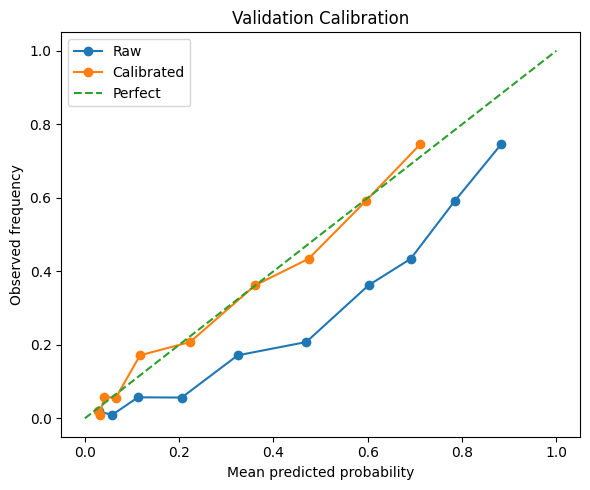

In [23]:
raw_true, raw_pred = calibration_curve(y_val, val_prob_raw, n_bins=10, strategy="quantile")
cal_true, cal_pred = calibration_curve(y_val, val_prob_cal, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,5))
plt.plot(raw_pred, raw_true, marker="o", label="Raw")
plt.plot(cal_pred, cal_true, marker="o", label="Calibrated")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Validation Calibration")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "calibration_curve.png", dpi=150)
plt.show()


## 13. Stage 14 — Decision threshold optimization

We do not assume 0.50 is the correct operating point. The threshold is selected using validation data only.

The current notebook uses **maximum validation F1** as a generic objective. If the business provides reliable FP/FN costs, replace this objective with expected-cost minimization.


In [24]:
threshold_rows = []

for threshold in np.linspace(0.05, 0.95, 181):
    pred = (val_prob_cal >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "fp": fp,
        "fn": fn
    })

threshold_df = pd.DataFrame(threshold_rows)
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
SELECTED_THRESHOLD = float(best_row["threshold"])

print("Selected threshold:", SELECTED_THRESHOLD)
display(threshold_df.sort_values("f1", ascending=False).head(10).round(4))


Selected threshold: 0.31499999999999995


,threshold,precision,recall,f1,fp,fn
53,0.315,0.5426,0.7964,0.6454,188,57
64,0.370,0.5671,0.7393,0.6419,158,73
58,0.340,0.5547,0.7607,0.6416,171,67
50,0.300,0.5318,0.8071,0.6411,199,54
62,0.360,0.5637,0.7429,0.6410,161,72
51,0.305,0.5346,0.8000,0.6409,195,56
63,0.365,0.5656,0.7393,0.6409,159,73
60,0.350,0.5585,0.7500,0.6402,166,70
54,0.320,0.5407,0.7821,0.6394,186,61
59,0.345,0.5553,0.7536,0.6394,169,69


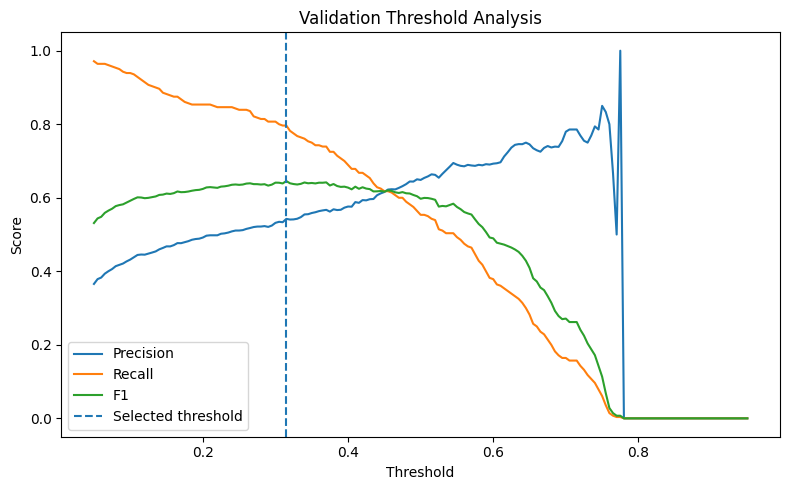

In [25]:
plt.figure(figsize=(8,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(SELECTED_THRESHOLD, linestyle="--", label="Selected threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Analysis")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_analysis.png", dpi=150)
plt.show()


## 14. Stage 7 ablation — Do engineered features help?

This experiment compares the engineered Logistic Regression pipeline with a version using only original features. The purpose is to demonstrate evidence-based feature engineering.


In [26]:
class NoOpFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.copy()

orig_num = X_train.select_dtypes(include=np.number).columns.tolist()
orig_cat = X_train.select_dtypes(exclude=np.number).columns.tolist()

orig_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), orig_num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), orig_cat)
])

original_features_model = Pipeline([
    ("features", NoOpFeatureEngineer()),
    ("preprocess", orig_preprocessor),
    ("model", LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE
    ))
])

engineered_features_model = make_pipeline(
    LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE
    )
)

ablation_rows = []
for name, model in [
    ("Original features", original_features_model),
    ("Original + engineered features", engineered_features_model)
]:
    model.fit(X_train, y_train)
    p = model.predict_proba(X_val)[:,1]
    r = evaluate_predictions(y_val, p)
    r["Model"] = name
    ablation_rows.append(r)

ablation_df = pd.DataFrame(ablation_rows).set_index("Model")
display(ablation_df.round(4))


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
Model,,,,,,,
Original features,0.7396,0.5055,0.8143,0.6238,0.8447,0.6308,0.1717
Original + engineered features,0.7348,0.5000,0.8286,0.6237,0.8506,0.6582,0.1668


## 15. Stage 15 — Explainability

For tree-based models, SHAP can provide global and individual explanations. The selected candidate may now be Random Forest, HistGradientBoosting, or XGBoost. The code below attempts SHAP if the package is installed.

**Interpretation rule:** SHAP describes the model's association with a prediction; it does not establish causation.


In [27]:
try:
    import shap

    X_sample = X_val.sample(min(500, len(X_val)), random_state=RANDOM_STATE)
    fitted_features = best_base_model.named_steps["features"]
    fitted_preprocess = best_base_model.named_steps["preprocess"]
    fitted_model = best_base_model.named_steps["model"]

    X_fe = fitted_features.transform(X_sample)
    X_encoded = fitted_preprocess.transform(X_fe)
    X_encoded = X_encoded.toarray() if hasattr(X_encoded, "toarray") else X_encoded
    feature_names = fitted_preprocess.get_feature_names_out()

    explainer = shap.Explainer(fitted_model, X_encoded, feature_names=feature_names)
    shap_values = explainer(X_encoded)

    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("SHAP was skipped. Install shap if you want the optional explanation section.")
    print("Reason:", repr(e))


SHAP was skipped. Install shap if you want the optional explanation section.
Reason: NotImplementedError('Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.')


## 16. Stage 16 — Error analysis

We inspect false positives and false negatives on validation data and compare their contract groups. This is intended to reveal where the model struggles rather than merely reporting a single score.


In [28]:
val_pred = (val_prob_cal >= SELECTED_THRESHOLD).astype(int)

errors = X_val.copy()
errors["actual_churn"] = y_val.values
errors["predicted_churn"] = val_pred
errors["churn_probability"] = val_prob_cal

errors["error_type"] = np.select(
    [
        (errors["actual_churn"] == 0) & (errors["predicted_churn"] == 1),
        (errors["actual_churn"] == 1) & (errors["predicted_churn"] == 0)
    ],
    ["False Positive", "False Negative"],
    default="Correct"
)

display(errors["error_type"].value_counts().to_frame("count"))

print("False negatives by contract:")
display(errors[errors.error_type=="False Negative"].groupby("Contract").size().to_frame("count"))

print("False positives by contract:")
display(errors[errors.error_type=="False Positive"].groupby("Contract").size().to_frame("count"))


,count
error_type,
Correct,811
False Positive,188
False Negative,57


False negatives by contract:


,count
Contract,
Month-to-month,31
One year,19
Two year,7


False positives by contract:


,count
Contract,
Month-to-month,185
One year,3


## 17. Stage 17–18 — Final model decision

The final model is selected from the tuned Random Forest, HistGradientBoosting, and XGBoost candidates using validation evidence. The decision considers PR-AUC, ROC-AUC, F1, calibration, stability and the business objective. Ensembling is not added unless an experiment demonstrates a meaningful improvement.


In [29]:
# Validation comparison at the frozen threshold
final_candidate_rows = []

for name, model in candidate_models.items():
    p = model.predict_proba(X_val)[:,1]
    r = evaluate_predictions(y_val, p, threshold=SELECTED_THRESHOLD)
    r["Model"] = name
    final_candidate_rows.append(r)

final_candidate_df = pd.DataFrame(final_candidate_rows).set_index("Model")
display(final_candidate_df.round(4))

print("Frozen selected candidate:", best_candidate_name)
print("Frozen threshold:", SELECTED_THRESHOLD)


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
Model,,,,,,,
Tuned Random Forest,0.6866,0.4542,0.9036,0.6045,0.8442,0.6353,0.1567
Tuned HistGradientBoosting,0.7708,0.5466,0.7964,0.6483,0.8511,0.6440,0.1340
Tuned XGBoost,0.6733,0.4444,0.9286,0.6012,0.8486,0.6440,0.1640


Frozen selected candidate: Tuned XGBoost
Frozen threshold: 0.31499999999999995


## 18. Stage 19 — Final untouched test evaluation

**This is the first and only final-test evaluation in the workflow.**

No tuning or threshold adjustment should be performed after viewing this result.


In [30]:
test_prob = calibrated_model.predict_proba(X_test)[:,1]
test_pred = (test_prob >= SELECTED_THRESHOLD).astype(int)

final_metrics = evaluate_predictions(
    y_test, test_prob, threshold=SELECTED_THRESHOLD
)

print("FINAL TEST METRICS")
display(pd.DataFrame([final_metrics]).round(4))

print("Classification report")
print(classification_report(
    y_test, test_pred,
    target_names=["No Churn", "Churn"], digits=4
))

cm = confusion_matrix(y_test, test_pred)
display(pd.DataFrame(
    cm,
    index=["Actual No Churn", "Actual Churn"],
    columns=["Predicted No Churn", "Predicted Churn"]
))


FINAL TEST METRICS


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,0.7729,0.5568,0.7153,0.6262,0.8396,0.6626,0.1389


Classification report
              precision    recall  f1-score   support

    No Churn     0.8851    0.7938    0.8370       776
       Churn     0.5568    0.7153    0.6262       281

    accuracy                         0.7729      1057
   macro avg     0.7209    0.7546    0.7316      1057
weighted avg     0.7978    0.7729    0.7809      1057



,Predicted No Churn,Predicted Churn
Actual No Churn,616,160
Actual Churn,80,201


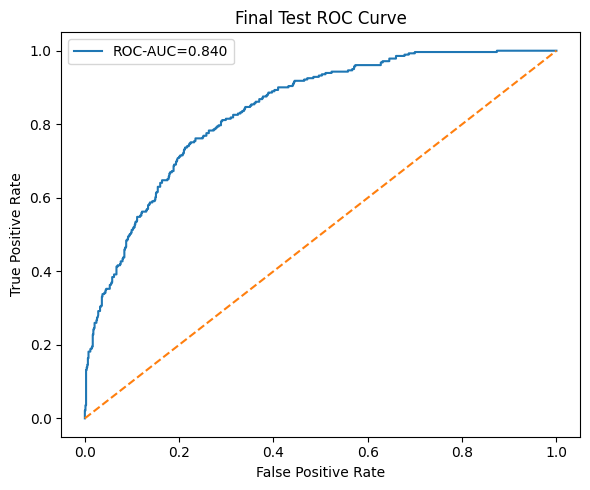

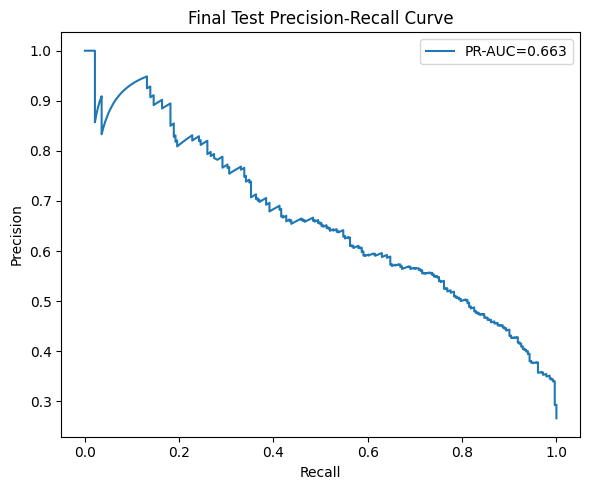

In [31]:
# Final ROC curve
fpr, tpr, _ = roc_curve(y_test, test_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC={final_metrics['ROC_AUC']:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Test ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_roc_curve.png", dpi=150)
plt.show()

# Final PR curve
precision, recall, _ = precision_recall_curve(y_test, test_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR-AUC={final_metrics['PR_AUC']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Test Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_pr_curve.png", dpi=150)
plt.show()


## 19. Stage 20 — Production-ready prediction function

The function accepts raw customer information and returns probability, prediction, risk level and a recommended retention action.

The same fitted preprocessing and calibration objects are reused at inference time.


In [32]:
def predict_customer(customer_data, model=calibrated_model, threshold=SELECTED_THRESHOLD):
    if isinstance(customer_data, dict):
        customer_df = pd.DataFrame([customer_data])
    elif isinstance(customer_data, pd.DataFrame):
        customer_df = customer_data.copy()
    else:
        raise TypeError("customer_data must be a dict or pandas DataFrame.")

    probability = model.predict_proba(customer_df)[:,1]
    prediction = (probability >= threshold).astype(int)

    risk_level = np.select(
        [probability >= 0.70, probability >= 0.40],
        ["High", "Medium"],
        default="Low"
    )

    action = np.select(
        [probability >= 0.70, probability >= 0.40],
        ["Prioritize retention outreach",
         "Monitor and consider targeted retention"],
        default="Standard customer engagement"
    )

    return pd.DataFrame({
        "churn_probability": probability,
        "prediction": prediction,
        "risk_level": risk_level,
        "recommended_action": action
    })


In [33]:
# Example using a real validation customer
example_customer = X_val.iloc[[0]].copy()
display(example_customer)
display(predict_customer(example_customer))


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6906,Female,0,Yes,Yes,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,18.7,383.65


,churn_probability,prediction,risk_level,recommended_action
0,0.026092,0,Low,Standard customer engagement


## 20. Stage 21 — Save the production artifact

The complete artifact includes the calibrated model, threshold, class mapping and reproducibility metadata. This avoids the common mistake of saving only a classifier while omitting required preprocessing.


In [34]:
artifact = {
    "model": calibrated_model,
    "threshold": SELECTED_THRESHOLD,
    "target_mapping": {"No": 0, "Yes": 1},
    "model_name": best_candidate_name,
    "random_state": RANDOM_STATE
}

artifact_path = ARTIFACT_DIR / "customer_churn_model.joblib"
joblib.dump(artifact, artifact_path)

metadata = {
    "model_name": best_candidate_name,
    "selected_threshold": SELECTED_THRESHOLD,
    "random_state": RANDOM_STATE,
    "final_test_metrics": final_metrics,
    "train_rows": len(X_train),
    "validation_rows": len(X_val),
    "test_rows": len(X_test),
    "positive_class": "Yes",
    "negative_class": "No"
}

with open(ARTIFACT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", artifact_path)
print("Saved:", ARTIFACT_DIR / "model_metadata.json")
print(json.dumps(metadata, indent=2))


Saved: artifacts/customer_churn_model.joblib
Saved: artifacts/model_metadata.json
{
  "model_name": "Tuned XGBoost",
  "selected_threshold": 0.31499999999999995,
  "random_state": 42,
  "final_test_metrics": {
    "Accuracy": 0.7729422894985809,
    "Precision": 0.556786703601108,
    "Recall": 0.7153024911032029,
    "F1": 0.6261682242990654,
    "ROC_AUC": 0.83963981729464,
    "PR_AUC": 0.6626309125498263,
    "Brier": 0.1388883061534068
  },
  "train_rows": 4930,
  "validation_rows": 1056,
  "test_rows": 1057,
  "positive_class": "Yes",
  "negative_class": "No"
}


# Final project checklist

- [x] Actual dataset inspected
- [x] Data-quality issues identified
- [x] Identifier removed
- [x] Hidden missing values handled
- [x] Stratified train/validation/test split
- [x] Leakage-safe preprocessing
- [x] Domain-informed feature engineering
- [x] Feature ablation
- [x] Logistic baseline
- [x] Tree-model benchmarking
- [x] XGBoost benchmarking
- [x] Stratified cross-validation
- [x] Randomized hyperparameter search
- [x] Random Forest tuning
- [x] HistGradientBoosting tuning
- [x] XGBoost tuning
- [x] Class-weight / class-imbalance handling
- [x] Probability calibration
- [x] Validation-only threshold optimization
- [x] SHAP explanation attempt
- [x] Validation error analysis
- [x] Untouched final test evaluation
- [x] Production prediction function
- [x] Joblib model artifact
- [x] Reproducibility metadata

**Important:** Do not tune the model after seeing the final test result. If the final test performance is weak, report it honestly and document what additional data or future experiments could improve it.
